In [1]:
# modules
import duckdb as db
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [2]:
# Loading data

apv = db.query("SELECT * FROM 'apv.parquet'").df()

mr = db.query("SELECT * FROM 'model_result.parquet'").df()

In [18]:
# Field Exam validation: Epidemiologically Aligned Proximity 
field_exam_validation = db.query(f"""
    WITH contact_evidence AS (
        SELECT 
            m.bovine_id,
            m.farm_id, m.risk_class,
            m.last_contact,
            m.vig_date,
            m.route_size,
            m.contact_order,
            m.p_deterministic,
            a.round_start,
            a.round_end,
            a.total_pos,
            CASE 
                -- PRIOR STATUS: previous found Outbreak
                WHEN CAST(a.round_end AS DATE) < CAST(m.last_contact AS DATE) 
                     AND date_diff('day', CAST(a.round_end AS DATE), CAST(m.last_contact AS DATE)) <= 180 
                     THEN 'Known_Source'
                
                -- INTERIM: Found after departure but before slaughter surveillance
                WHEN CAST(a.round_start AS DATE) >= CAST(m.last_contact AS DATE) 
                     AND CAST(a.round_start AS DATE) < CAST(m.vig_date AS DATE)
                                 AND date_diff('day', CAST(m.last_contact AS DATE), CAST(a.round_start AS DATE)) <= 1095
                     THEN 'Prospective_Discovery'
                
                -- TRIGGERED: Found because of our slaughterhouse surveillance
                WHEN CAST(a.round_start AS DATE) >= CAST(m.vig_date AS DATE) 
                                 AND date_diff('day', CAST(m.last_contact AS DATE), CAST(a.round_start AS DATE)) <= 1095
                     THEN 'Prospective_Discovery'
                ELSE 'Ignore'
            END AS match_type,
            CASE WHEN a.total_pos > 0 THEN 'Evidence of Infection' ELSE 'Confirmed Negative' END AS field_status
        FROM mr m
            JOIN apv a ON m.farm_id = a.farm_id
        WHERE (a.total_pos > 0 OR a.sampling_confidence IN ('Gold Standard', 'Acceptable'))
    ),
    ranked_matches AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY bovine_id, farm_id 
                   ORDER BY 
                       -- Known Source trumps all to avoid "surveillance credit" for ongoing outbreaks
                       CASE WHEN match_type = 'Known_Source' THEN 0 ELSE 1 END,
                       -- Cast added here to fix the BinderException
                       ABS(date_diff('day', CAST(last_contact AS TIMESTAMP), CAST(round_start AS TIMESTAMP))) ASC
               ) as rank
        FROM contact_evidence
        WHERE match_type != 'Ignore'
    )
    SELECT * FROM ranked_matches WHERE rank = 1
""").df()

def get_metrics(df):
    # Split groups
    high = df[df['risk_class'] == 'High']
    medium = df[df['risk_class'] == 'Medium']
    low = df[df['risk_class'] == 'Low']
    
    # Calculate PPVs (Point Estimates)
    ppv_high = (high['field_status'] == 'Evidence of Infection').mean()
    ppv_medium = (medium['field_status'] == 'Evidence of Infection').mean()
    ppv_low = (low['field_status'] == 'Evidence of Infection').mean()
    
    # --- High vs Low Relative Risk and 95% CI (Katz Method) ---
    a = (high['field_status'] == 'Evidence of Infection').sum()
    n1 = len(high)
    c = (low['field_status'] == 'Evidence of Infection').sum()
    n2 = len(low)
    
    rr_hl = ppv_high / ppv_low
    
    # Standard Error of ln(RR)
    # Formula: sqrt( (1/a - 1/n1) + (1/c - 1/n2) )
    se_ln_rr = np.sqrt((1/a - 1/n1) + (1/c - 1/n2))
    
    # 95% Confidence Interval limits (z=1.96)
    ci_low = np.exp(np.log(rr_hl) - 1.96 * se_ln_rr)
    ci_high = np.exp(np.log(rr_hl) + 1.96 * se_ln_rr)
    
    return {
        "Total Validated contacts": len(df),
        "PPV High Risk": f"{ppv_high:.2%}",
        "PPV Medium Risk": f"{ppv_medium:.2%}",
        "PPV Low Risk": f"{ppv_low:.2%}",
        "High-Low Relative Risk (RR)": f"{rr_hl:.2f}x",
        "High-Low RR 95% CI": f"[{ci_low:.2f} - {ci_high:.2f}]",
        "Medium-Low Relative Risk (RR)": f"{ppv_medium/ppv_low:.2f}x"
    }

# Matrix and Metrics execution
matrix = pd.crosstab(field_exam_validation['risk_class'], field_exam_validation['field_status'])
print("--- Validation Matrix ---")
print(matrix)

print("\n--- Performance Metrics ---")
metrics = get_metrics(field_exam_validation)
for k, v in metrics.items():
    print(f"{k}: {v}")

--- Validation Matrix ---
field_status  Confirmed Negative  Evidence of Infection
risk_class                                             
High                         272                    104
Low                          132                     10
Medium                       132                     12

--- Performance Metrics ---
Total Validated contacts: 662
PPV High Risk: 27.66%
PPV Medium Risk: 8.33%
PPV Low Risk: 7.04%
High-Low Relative Risk (RR): 3.93x
High-Low RR 95% CI: [2.11 - 7.30]
Medium-Low Relative Risk (RR): 1.18x


In [15]:
def get_metrics(df):
    # Split groups
    high = df[df['risk_class'] == 'High']
    medium = df[df['risk_class'] == 'Medium']
    low = df[df['risk_class'] == 'Low']
    
    # PPV: P(Infection | Risk Class)
    ppv_high = (high['field_status'] == 'Evidence of Infection').mean()
    ppv_medium = (medium['field_status'] == 'Evidence of Infection').mean()
    ppv_low = (low['field_status'] == 'Evidence of Infection').mean()
    
    # NPV (VNP): P(Negative | Risk Class)
    # Calculated for Low Risk as it represents the model's 'negative' prediction
    npv_low = (low['field_status'] == 'Confirmed Negative').mean()
    
    # --- High vs Low Relative Risk and 95% CI (Katz Method) ---
    a = (high['field_status'] == 'Evidence of Infection').sum()
    n1 = len(high)
    c = (low['field_status'] == 'Evidence of Infection').sum()
    n2 = len(low)
    
    rr_hl = ppv_high / ppv_low
    
    # Standard Error of ln(RR)
    se_ln_rr = np.sqrt((1/a - 1/n1) + (1/c - 1/n2))
    
    # 95% Confidence Interval (z=1.96)
    ci_low = np.exp(np.log(rr_hl) - 1.96 * se_ln_rr)
    ci_high = np.exp(np.log(rr_hl) + 1.96 * se_ln_rr)
    
    return {
        "Total Validated contacts": len(df),
        "PPV High Risk": f"{ppv_high:.2%}",
        "PPV Medium Risk": f"{ppv_medium:.2%}",
        "PPV Low Risk": f"{ppv_low:.2%}",
        "NPV Low Risk (VNP)": f"{npv_low:.2%}",
        "High-Low Relative Risk (RR)": f"{rr_hl:.2f}x",
        "High-Low RR 95% CI": f"[{ci_low:.2f} - {ci_high:.2f}]",
        "Medium-Low Relative Risk (RR)": f"{ppv_medium/ppv_low:.2f}x"
    }

# --- Validation of surveillance success cases ---

# 1. Identify "succeeded Anchors" 
# (Bovine IDs where at least one contact farm was confirmed positive in the field)
succeeded_bovine_ids = field_exam_validation[
    field_exam_validation['field_status'] == 'Evidence of Infection'
]['bovine_id'].unique()

# 2. Filter the validation dataframe to only include these surveillance success cases
fair_validation = field_exam_validation[
    field_exam_validation['bovine_id'].isin(succeeded_bovine_ids)
]

# 3. Execution and Comparison
print(f"Total slaughterhouse anchors investigated: {field_exam_validation['bovine_id'].nunique()}")
print(f"Succeeded anchors (source found in field): {len(succeeded_bovine_ids)}")
print(f"Percentage of 'Cold Cases' excluded: {(1 - len(succeeded_bovine_ids)/field_exam_validation['bovine_id'].nunique()):.1%}")

print("\n--- 'Fair' Validation Matrix (surveillance success cases Only) ---")
fair_matrix = pd.crosstab(fair_validation['risk_class'], fair_validation['field_status'])
print(fair_matrix)

print("\n--- 'Fair' Performance Metrics ---")
fair_results = get_metrics(fair_validation)
for k, v in fair_results.items():
    print(f"{k}: {v}")

Total slaughterhouse anchors investigated: 398
Succeeded anchors (source found in field): 121
Percentage of 'Cold Cases' excluded: 69.6%

--- 'Fair' Validation Matrix (surveillance success cases Only) ---
field_status  Confirmed Negative  Evidence of Infection
risk_class                                             
High                          42                    104
Low                           24                     10
Medium                        30                     12

--- 'Fair' Performance Metrics ---
Total Validated contacts: 222
PPV High Risk: 71.23%
PPV Medium Risk: 28.57%
PPV Low Risk: 29.41%
NPV Low Risk (VNP): 70.59%
High-Low Relative Risk (RR): 2.42x
High-Low RR 95% CI: [1.42 - 4.12]
Medium-Low Relative Risk (RR): 0.97x


In [4]:
def print_validation_report(df, title):
    print(f"\n{'='*60}")
    print(f" {title} ")
    print(f"{'='*60}")
    
    if df.empty:
        print("No data found for this category.")
        return

    matrix = pd.crosstab(df['risk_class'], df['field_status'])
    print("\n--- Validation Matrix ---")
    print(matrix)
    
    # Using the same metrics function we defined earlier
    metrics = get_metrics(df)
    print("\n--- Performance Metrics ---")
    for k, v in metrics.items():
        print(f"{k}: {v}")

In [5]:
known_source_df = field_exam_validation[(field_exam_validation['match_type'] == 'Known_Source') 
                                        #& (field_exam_validation['route_size'] > 1 )
                                        ]
print_validation_report(known_source_df, "KNOWN SOURCES")


 KNOWN SOURCES 

--- Validation Matrix ---
field_status  Confirmed Negative  Evidence of Infection
risk_class                                             
High                          57                     22
Low                           53                      0
Medium                        25                      0

--- Performance Metrics ---
Total Validated contacts: 157
PPV High Risk: 27.85%
PPV Medium Risk: 0.00%
PPV Low Risk: 0.00%
High-Low Relative Risk (RR): infx
Medium-Low Relative Risk (RR): nanx


C:\Users\FELIPE\AppData\Local\Temp\ipykernel_13860\2345947333.py:73: RuntimeWarning: divide by zero encountered in scalar divide
  "High-Low Relative Risk (RR)": f"{ppv_high/ppv_low:.2f}x",
C:\Users\FELIPE\AppData\Local\Temp\ipykernel_13860\2345947333.py:74: RuntimeWarning: invalid value encountered in scalar divide
  "Medium-Low Relative Risk (RR)" : f"{ppv_medium/ppv_low:.2f}x"


In [6]:
prospective_df = field_exam_validation[(field_exam_validation['match_type'] == 'Prospective_Discovery')
                                       # & (field_exam_validation['route_size'] > 1 )
                                       ]
print_validation_report(prospective_df, "PROSPECTIVE DISCOVERIES")


 PROSPECTIVE DISCOVERIES 

--- Validation Matrix ---
field_status  Confirmed Negative  Evidence of Infection
risk_class                                             
High                         215                     82
Low                           79                     10
Medium                       107                     12

--- Performance Metrics ---
Total Validated contacts: 505
PPV High Risk: 27.61%
PPV Medium Risk: 10.08%
PPV Low Risk: 11.24%
High-Low Relative Risk (RR): 2.46x
Medium-Low Relative Risk (RR): 0.90x


In [8]:
# 1. Filter the data for Prospective Discoveries in complex routes
# This matches the scenario where your PPV was 22.7%
prospective_complex = field_exam_validation[
    (field_exam_validation['match_type'] == 'Prospective_Discovery') & 
    (field_exam_validation['route_size'] > 1)
]

# 2. Isolate the Low Risk category
low_risk_group = prospective_complex[prospective_complex['risk_class'] == 'Low']

# 3. Calculate components for NPV
# True Negatives (TN): Model said Low Risk, Field confirmed Negative
true_negatives = (low_risk_group['field_status'] == 'Confirmed Negative').sum()

# Total Low Risk: All samples the model suggested were safe
total_low_risk = len(low_risk_group)

# 4. Calculate NPV (Negative Predictive Value)
# NPV = True Negatives / Total predicted as Low Risk
npv = (true_negatives / total_low_risk) * 100 if total_low_risk > 0 else 0

# 5. Display results
print(f"--- Negative Predictive Value (NPV) Analysis ---")
print(f"Total properties classified as LOW RISK: {total_low_risk}")
print(f"Number of these correctly found NEGATIVE (True Negatives): {true_negatives}")
print(f"Number of missed infections (False Negatives): {total_low_risk - true_negatives}")
print(f"NPV: {npv:.2f}%")

# Optional: Comparison with the overall sample prevalence
global_prevalence = (prospective_complex['field_status'] == 'Evidence of Infection').mean() * 100
print(f"\nBackground Prevalence in this group: {global_prevalence:.2f}%")
print(f"Confidence Increase: Your model is {npv - (100 - global_prevalence):.2f}% safer than random skipping.")

--- Negative Predictive Value (NPV) Analysis ---
Total properties classified as LOW RISK: 89
Number of these correctly found NEGATIVE (True Negatives): 79
Number of missed infections (False Negatives): 10
NPV: 88.76%

Background Prevalence in this group: 16.63%
Confidence Increase: Your model is 5.39% safer than random skipping.


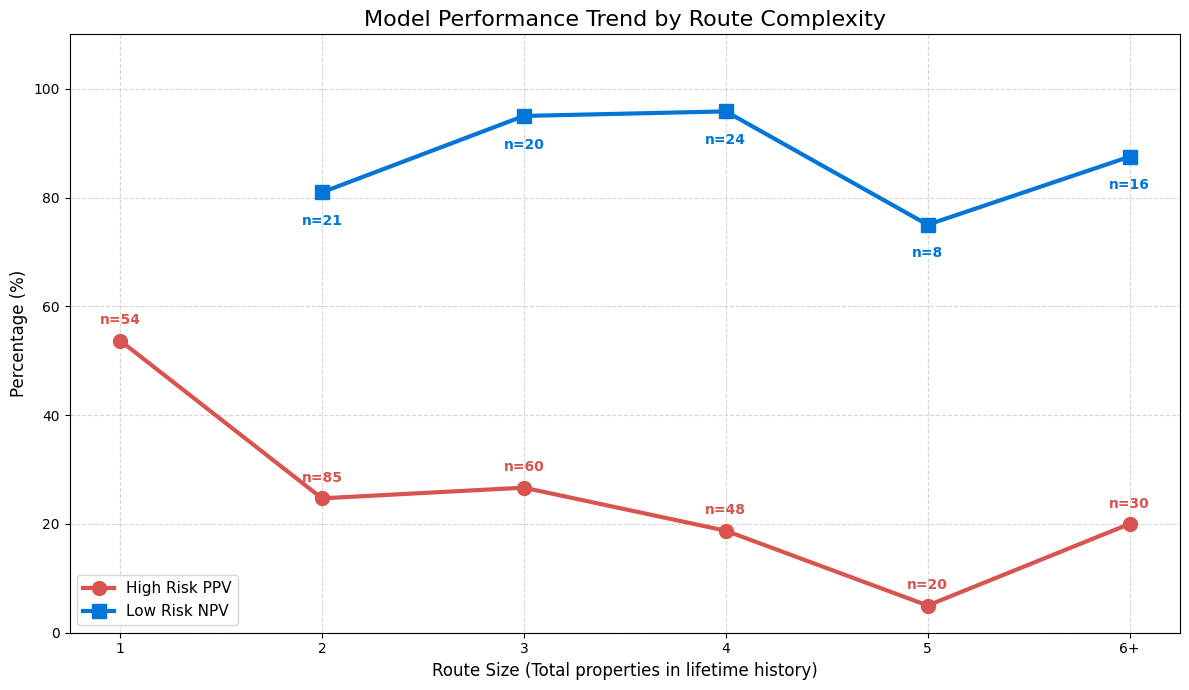

In [9]:
# 1. Filter for Prospective results and prepare the route bins
df_trend = field_exam_validation[field_exam_validation['match_type'] == 'Prospective_Discovery'].copy()
df_trend['route_bin'] = df_trend['route_size'].apply(lambda x: str(int(x)) if x < 6 else '6+')

# 2. Function to calculate metrics per route size
def get_route_metrics(group):
    high_risk = group[group['risk_class'] == 'High']
    low_risk = group[group['risk_class'] == 'Low']
    
    # PPV: Accuracy of the "Attack" (High Risk class)
    ppv = (high_risk['field_status'] == 'Evidence of Infection').mean() * 100 if len(high_risk) > 0 else np.nan
    
    # NPV: Safety of the "Shield" (Low Risk class)
    npv = (low_risk['field_status'] == 'Confirmed Negative').mean() * 100 if len(low_risk) > 0 else np.nan
    
    return pd.Series({
        'PPV': ppv, 
        'NPV': npv, 
        'n_High': len(high_risk), 
        'n_Low': len(low_risk)
    })

# 3. Aggregate results and sort logically
trend_stats = df_trend.groupby('route_bin').apply(get_route_metrics).reset_index()
trend_stats['sort_key'] = trend_stats['route_bin'].apply(lambda x: int(x) if x.isdigit() else 99)
trend_stats = trend_stats.sort_values('sort_key').drop('sort_key', axis=1)

# 4. Plotting the performance trend
plt.figure(figsize=(12, 7))

# Plot PPV (The Attack)
plt.plot(trend_stats['route_bin'], trend_stats['PPV'], marker='o', label='High Risk PPV', 
         color='#d9534f', linewidth=3, markersize=10)

# Plot NPV (The Shield)
plt.plot(trend_stats['route_bin'], trend_stats['NPV'], marker='s', label='Low Risk NPV', 
         color='#0275d8', linewidth=3, markersize=10)

# Add sample size annotations to prevent misinterpretation of small N
for i, row in trend_stats.iterrows():
    if not np.isnan(row['PPV']):
        plt.text(i, row['PPV'] + 3, f"n={int(row['n_High'])}", color='#d9534f', ha='center', fontweight='bold')
    if not np.isnan(row['NPV']):
        plt.text(i, row['NPV'] - 6, f"n={int(row['n_Low'])}", color='#0275d8', ha='center', fontweight='bold')

plt.title('Model Performance Trend by Route Complexity', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Route Size (Total properties in lifetime history)', fontsize=12)
plt.ylim(0, 110)
plt.legend(loc='lower left', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np

# 1. Prepare prospective data (within the 3-year window defined in SQL)
df_gap = field_exam_validation[field_exam_validation['match_type'] == 'Prospective_Discovery'].copy()

# 2. Calculate metrics per risk class to evaluate classification performance
def calc_risk_gap(df):
    results = []
    for r_class in ['High', 'Medium', 'Low']:
        subset = df[df['risk_class'] == r_class]
        pos = (subset['field_status'] == 'Evidence of Infection').sum()
        total = len(subset)
        ppv = (pos / total) if total > 0 else 0
        results.append({
            'Class': r_class, 
            'Positives': pos, 
            'Total': total, 
            'PPV%': ppv * 100
        })
    return pd.DataFrame(results)

gap_table = calc_risk_gap(df_gap)

# 3. Calculate Relative Risk (RR) using 'Low' class as baseline reference
ppv_low = gap_table.loc[gap_table['Class'] == 'Low', 'PPV%'].values[0]

# RR measures how many times more likely we are to find a focus compared to the baseline
gap_table['RR_vs_Low'] = gap_table['PPV%'] / ppv_low

print("--- Risk Class Performance Comparison for Prospective Discovery ---")
print(gap_table.to_string(index=False))

# 4. Management Insights (for Discussion section)
rr_med = gap_table.loc[gap_table['Class'] == 'Medium', 'RR_vs_Low'].values[0]
rr_high = gap_table.loc[gap_table['Class'] == 'High', 'RR_vs_Low'].values[0]

print(f"\nMedium Risk finds {rr_med:.2f}x more outbreaks than Low Risk.")
print(f"High Risk finds {rr_high:.2f}x more outbreaks than Low Risk.")

--- Risk Class Performance Comparison for Prospective Discovery ---
 Class  Positives  Total      PPV%  RR_vs_Low
  High         82    297 27.609428   2.457239
Medium         12    119 10.084034   0.897479
   Low         10     89 11.235955   1.000000

Medium Risk finds 0.90x more outbreaks than Low Risk.
High Risk finds 2.46x more outbreaks than Low Risk.
